# Driver and Constructor Dominance in Formula 1 (1950–2025)

This notebook focuses on competitive dynamics and dominance patterns in Formula 1 across its modern history.

While the previous notebook provided a structural overview of the championship, the goal here is to move one level deeper and analyze who actually wins, how concentrated success is, and how dominance changes across different eras of Formula 1.

The analysis is centered around race outcomes and is designed to answer the following questions:

- How concentrated are race wins among constructors and drivers?

- Do certain periods of Formula 1 history exhibit strong dominance by a small number of teams or individuals?

- How does dominance differ between constructors and drivers?

- Can Top-3 finishes be used as a more stable and informative performance metric than wins alone?

To ensure interpretability and consistency across eras, this notebook primarily relies on race-level results and avoids predictive modeling or fine-grained telemetry data. The focus is on descriptive and comparative analysis rather than forecasting.

The findings from this notebook will serve as a foundation for later stages of the project, including performance modeling and machine learning tasks

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_data

results = load_data('results')
races = load_data('races')
drivers = load_data('drivers')
constructors = load_data('constructors')

# Constructor Dominance

In this block we make analys for top1 constructor in each year

In [23]:
constructor_win_by_year = (
    results[results['positionOrder'] == 1]
    .merge(races[['raceId', 'year']], on='raceId', how='left')
    .groupby(['year', 'constructorId'])
    .size()
    .reset_index(name='wins')
)


In [25]:
constructor_win_by_year = (
    constructor_win_by_year
    .merge(constructors[['constructorId', 'name']], on='constructorId', how='left')
)

constructor_win_by_year = constructor_win_by_year[['year', 'name', 'wins']]

constructor_win_by_year = constructor_win_by_year.sort_values(
    ['year', 'wins'],
    ascending=[True, False]
)

In [26]:
constructor_win_by_year['total_races'] = constructor_win_by_year.groupby(['year'])['wins'].transform('sum')

In [27]:
constructor_win_by_year

,year,name,wins,total_races
0,1950,Alfa Romeo,6,7
1,1950,Kurtis Kraft,1,7
3,1951,Alfa Romeo,5,9
2,1951,Ferrari,3,9
4,1951,Kurtis Kraft,1,9
...,...,...,...,...
274,2024,Ferrari,5,24
276,2024,Mercedes,4,24
277,2025,McLaren,14,24
278,2025,Red Bull,8,24


In [32]:
constructor_win_by_year['winning_percent'] = ((
    constructor_win_by_year['wins'] / constructor_win_by_year['total_races']
) * 100).round(2)

constructor_win_by_year

,year,name,wins,total_races,winning_percent
0,1950,Alfa Romeo,6,7,85.71
1,1950,Kurtis Kraft,1,7,14.29
3,1951,Alfa Romeo,5,9,55.56
2,1951,Ferrari,3,9,33.33
4,1951,Kurtis Kraft,1,9,11.11
...,...,...,...,...,...
274,2024,Ferrari,5,24,20.83
276,2024,Mercedes,4,24,16.67
277,2025,McLaren,14,24,58.33
278,2025,Red Bull,8,24,33.33


In [33]:
idx = constructor_win_by_year.groupby(['year'])['winning_percent'].idxmax()
constructor_season_dominance = constructor_win_by_year.loc[idx]

constructor_season_dominance

,year,name,wins,total_races,winning_percent
0,1950,Alfa Romeo,6,7,85.71
3,1951,Alfa Romeo,5,9,55.56
5,1952,Ferrari,7,8,87.50
7,1953,Ferrari,7,9,77.78
13,1954,Mercedes,4,9,44.44
...,...,...,...,...,...
265,2021,Red Bull,11,22,50.00
269,2022,Red Bull,17,22,77.27
272,2023,Red Bull,21,22,95.45
275,2024,Red Bull,9,24,37.50


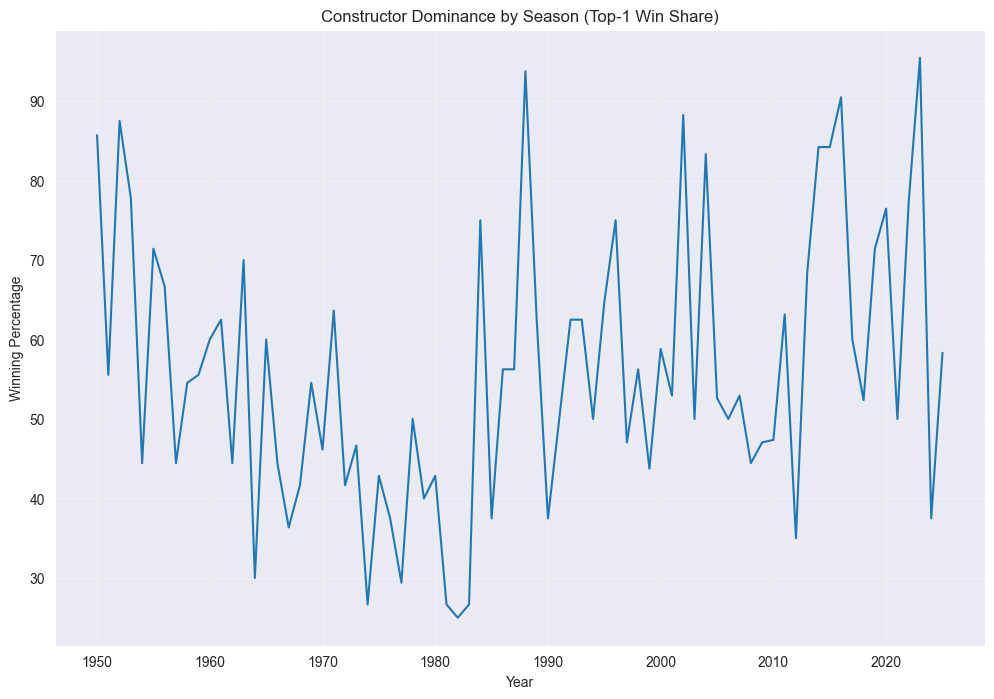

In [35]:
plt.figure(figsize = (12, 8))

plt.plot(constructor_season_dominance.year, constructor_season_dominance.winning_percent)
plt.xlabel('Year')
plt.ylabel('Winning Percentage')
plt.title('Constructor Dominance by Season (Top-1 Win Share)')
plt.grid(alpha=0.3)

plt.show()

### Key Observations

Based on the top-1 constructor winning share by season, several distinct eras can be identified:

1. **1950–1960s:**
   The early years of Formula 1 were characterized by **strong constructor dominance**, with leading teams frequently winning a very high proportion of races within a season.

2. **1970s:**
   This period shows a noticeable **increase in competitiveness**, with the top constructor’s share of wins declining, indicating a more balanced distribution of race victories.

3. **Late 1980s – Early 1990s:**
   A renewed phase of **constructor dominance** is visible, largely driven by teams such as **McLaren**, which achieved a high concentration of wins in several seasons.

4. **2000s–2020s:**
   Formula 1 enters an era of **cyclical dominance**, where prolonged periods of high dominance by a single constructor — notably **Ferrari (early 2000s)**, **Mercedes (mid-2010s)**, and **Red Bull (early 2020s)** — are separated by more competitive transitional seasons.


# Driver Dominance


In [44]:
driver_win_by_year = (
    results[results['positionOrder'] == 1]
    .merge(races[['raceId', 'year']], on='raceId')
    .groupby(['year', 'driverId'])
    .size()
    .reset_index(name='wins')
)

driver_win_by_year = (
    driver_win_by_year
    .merge(drivers[['driverId', 'forename', 'surname']], on='driverId', how='left')
)

driver_win_by_year['name'] = driver_win_by_year['forename'] + ' ' + driver_win_by_year['surname']
driver_win_by_year = driver_win_by_year[['year', 'name', 'wins']]

driver_win_by_year['total_races'] = driver_win_by_year.groupby(['year'])['wins'].transform('sum')
driver_win_by_year['winning_percent'] = ((driver_win_by_year['wins'] / driver_win_by_year['total_races']) * 100).round(2)
driver_win_by_year

,year,name,wins,total_races,winning_percent
0,1950,Juan Fangio,3,7,42.86
1,1950,Johnnie Parsons,1,7,14.29
2,1950,Nino Farina,3,7,42.86
3,1951,José Froilán González,1,9,11.11
4,1951,Juan Fangio,3,9,33.33
...,...,...,...,...,...
402,2024,Oscar Piastri,2,24,8.33
403,2025,Max Verstappen,8,24,33.33
404,2025,Lando Norris,7,24,29.17
405,2025,George Russell,2,24,8.33


In [45]:
idx = driver_win_by_year.groupby(['year'])['winning_percent'].idxmax()
driver_season_dominance = driver_win_by_year.loc[idx]

In [46]:
driver_season_dominance

,year,name,wins,total_races,winning_percent
0,1950,Juan Fangio,3,7,42.86
4,1951,Juan Fangio,3,9,33.33
11,1952,Alberto Ascari,6,8,75.00
15,1953,Alberto Ascari,5,9,55.56
19,1954,Juan Fangio,6,9,66.67
...,...,...,...,...,...
386,2021,Max Verstappen,10,22,45.45
389,2022,Max Verstappen,15,22,68.18
394,2023,Max Verstappen,19,22,86.36
397,2024,Max Verstappen,9,24,37.50


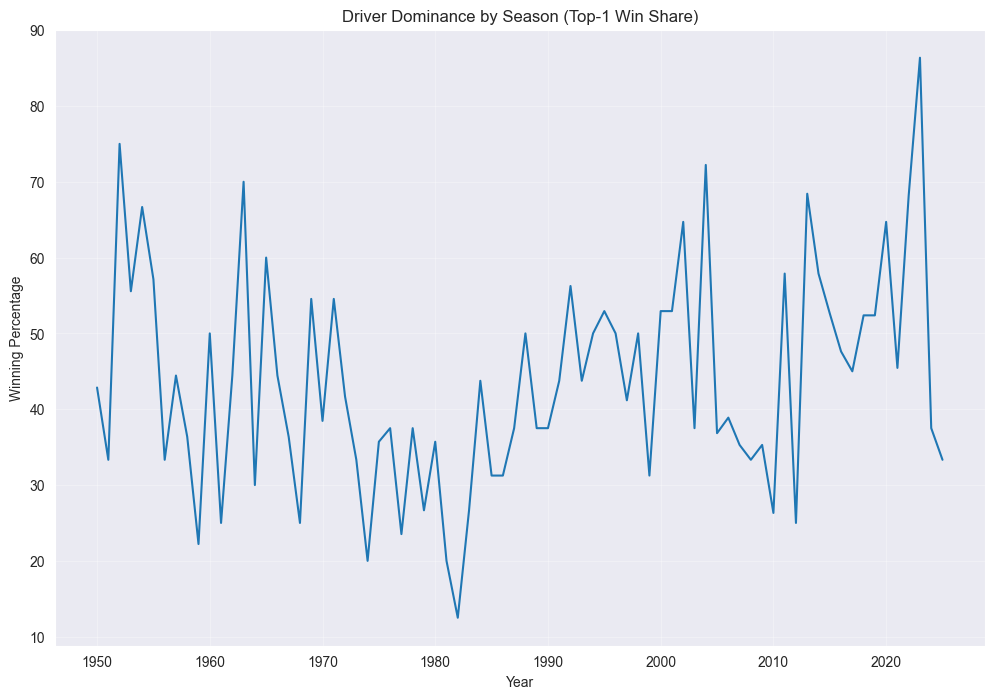

In [47]:
plt.figure(figsize = (12, 8))
plt.plot(driver_season_dominance.year, driver_season_dominance.winning_percent)
plt.xlabel('Year')
plt.ylabel('Winning Percentage')
plt.title('Driver Dominance by Season (Top-1 Win Share)')
plt.grid(alpha=0.3)
plt.show()

### Driver Dominance by Season

The driver-level dominance metric reveals a more volatile and individualized pattern compared to constructor dominance.

In the early years of Formula 1, particularly the 1950s, several seasons exhibit **very high driver dominance**, most notably driven by **Juan Manuel Fangio**, whose win share often exceeded 60–70%. This reflects an era where individual driver skill played a disproportionately large role relative to team depth and technical parity.

From the late 1960s through the 1970s, the championship shows a sustained period of **lower driver dominance**, indicating a more competitive environment with race victories distributed across multiple drivers.

Starting in the early 2000s, sharp spikes in dominance reappear, corresponding to well-known eras of individual excellence, including **Michael Schumacher**, **Sebastian Vettel**, **Lewis Hamilton**, and more recently **Max Verstappen**. These peaks often exceed 60% win share, highlighting seasons where a single driver overwhelmingly outperformed the field.

Overall, driver dominance displays **greater variability** than constructor dominance, suggesting that while teams provide the competitive foundation, exceptional drivers can still create highly asymmetric seasons.


In [51]:
top3_constructor_win_by_year = (
    constructor_win_by_year
    .groupby('year')
    .apply(lambda x: x.nlargest(3, 'wins'))
    .reset_index(level=0)
)

top3_constructor_win_by_year


,year,name,wins,total_races,winning_percent
0,1950,Alfa Romeo,6,7,85.71
1,1950,Kurtis Kraft,1,7,14.29
3,1951,Alfa Romeo,5,9,55.56
2,1951,Ferrari,3,9,33.33
4,1951,Kurtis Kraft,1,9,11.11
...,...,...,...,...,...
273,2024,McLaren,6,24,25.00
274,2024,Ferrari,5,24,20.83
277,2025,McLaren,14,24,58.33
278,2025,Red Bull,8,24,33.33


In [52]:
constructor_top3_season_dominance = (
    top3_constructor_win_by_year
    .groupby('year', as_index=False)
    .agg(
        top3_wins=('wins', 'sum'),
        total_races=('total_races', 'first')
    )
)

constructor_top3_season_dominance['top3_share'] = (
    constructor_top3_season_dominance['top3_wins'] / constructor_top3_season_dominance['total_races']
) * 100

constructor_top3_season_dominance

,year,top3_wins,total_races,top3_share
0,1950,7,7,100.000000
1,1951,9,9,100.000000
2,1952,8,8,100.000000
3,1953,9,9,100.000000
4,1954,8,9,88.888889
...,...,...,...,...
71,2021,21,22,95.454545
72,2022,22,22,100.000000
73,2023,22,22,100.000000
74,2024,20,24,83.333333


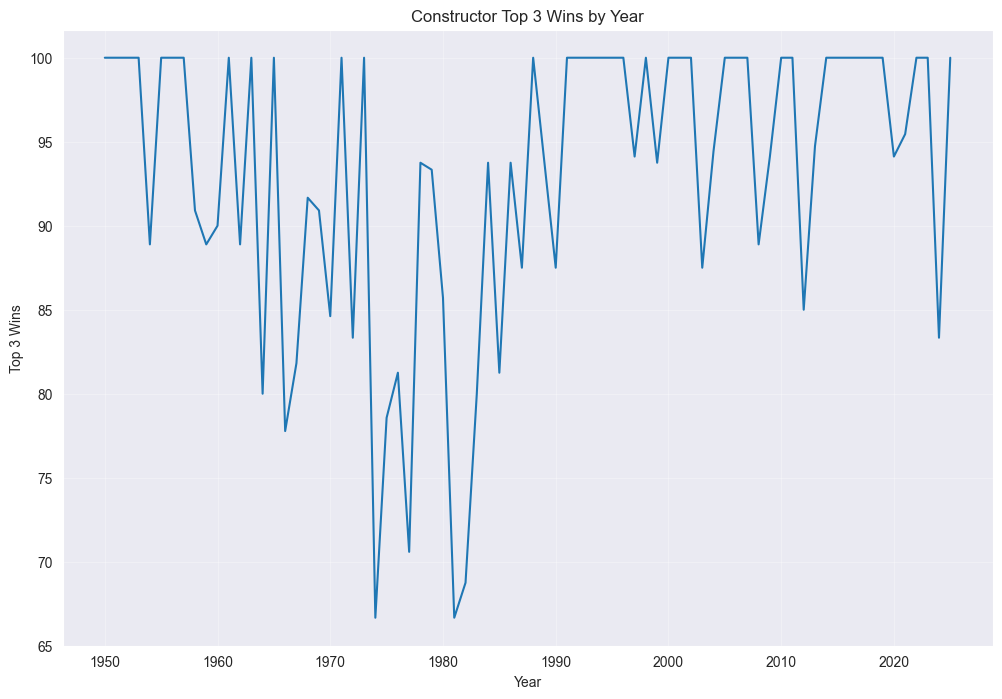

In [53]:
plt.figure(figsize=(12, 8))
plt.plot(constructor_top3_season_dominance.year, constructor_top3_season_dominance.top3_share)
plt.xlabel('Year')
plt.ylabel('Top 3 Wins')
plt.title('Constructor Top 3 Wins by Year')
plt.grid(alpha=0.3)
plt.show()

### Top-3 Constructor Dominance by Season

The top-3 constructor dominance metric highlights how race victories in Formula 1 are often concentrated among a small group of teams.

Across most seasons, the combined win share of the three most successful constructors exceeds **85–90%**, indicating that Formula 1 has historically been characterized by **strong oligopolistic structures**, rather than evenly distributed competition.

Periods where the top-3 win share approaches **100%** suggest seasons in which virtually all race victories were captured by a very limited number of teams, leaving little opportunity for the rest of the grid to compete for wins.

Notably, the lowest top-3 dominance values occur primarily during the **1970s and early 1980s**, reflecting a comparatively more diverse distribution of race winners and a higher level of competitive unpredictability.

In more recent decades, top-3 dominance has remained consistently high, reinforcing the notion that while individual team dominance may fluctuate, overall competition at the front of the grid is typically confined to a small subset of constructors.


## Top3 Dominance by drivers

In [54]:
top3_drivers_win_by_year = (
    driver_win_by_year
    .groupby('year')
    .apply(lambda x: x.nlargest(3, 'wins'))
    .reset_index(level=0)
)

top3_drivers_win_by_year

,year,name,wins,total_races,winning_percent
0,1950,Juan Fangio,3,7,42.86
2,1950,Nino Farina,3,7,42.86
1,1950,Johnnie Parsons,1,7,14.29
4,1951,Juan Fangio,3,9,33.33
6,1951,Alberto Ascari,2,9,22.22
...,...,...,...,...,...
400,2024,Lando Norris,4,24,16.67
399,2024,Charles Leclerc,3,24,12.50
403,2025,Max Verstappen,8,24,33.33
404,2025,Lando Norris,7,24,29.17


In [55]:
driver_top3_season_dominance = (
    top3_drivers_win_by_year
    .groupby('year', as_index=False)
    .agg(
        top3_wins=('wins', 'sum'),
        total_races=('total_races', 'first')
    )
)

driver_top3_season_dominance['top3_share'] = (
    constructor_top3_season_dominance['top3_wins'] / constructor_top3_season_dominance['total_races']
) * 100

driver_top3_season_dominance

,year,top3_wins,total_races,top3_share
0,1950,7,7,100.000000
1,1951,6,9,100.000000
2,1952,8,8,100.000000
3,1953,7,9,100.000000
4,1954,8,9,88.888889
...,...,...,...,...
71,2021,19,22,95.454545
72,2022,20,22,100.000000
73,2023,22,22,100.000000
74,2024,16,24,83.333333


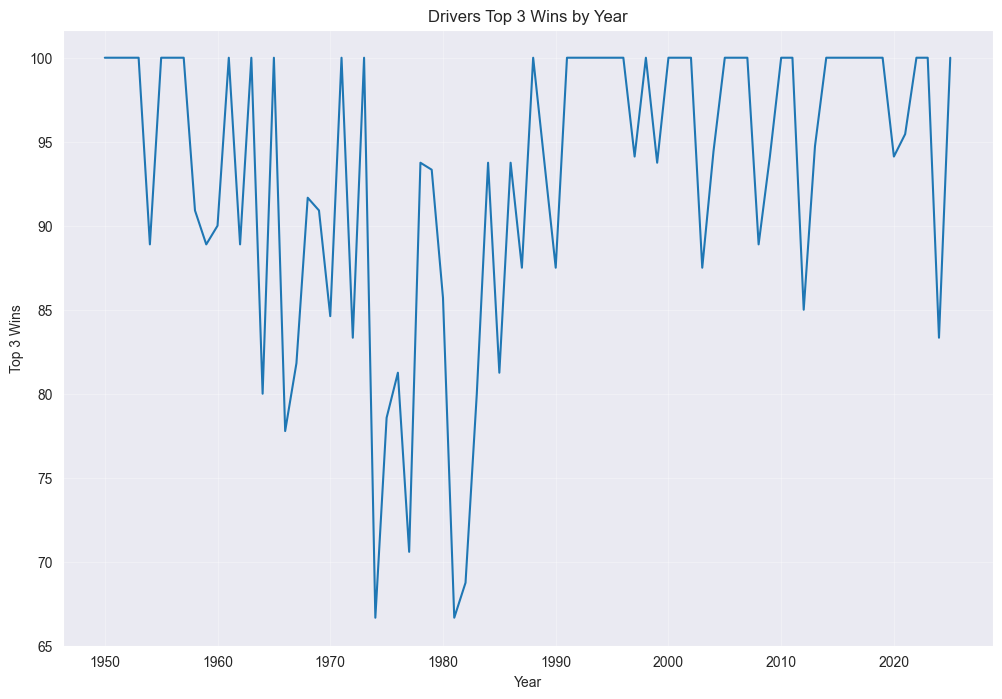

In [56]:
plt.figure(figsize=(12, 8))
plt.plot(driver_top3_season_dominance.year, driver_top3_season_dominance.top3_share)
plt.xlabel('Year')
plt.ylabel('Top 3 Wins')
plt.title('Drivers Top 3 Wins by Year')
plt.grid(alpha=0.3)
plt.show()

### Top-3 Driver Dominance by Season

The top-3 driver dominance metric demonstrates that, similar to constructors, race victories in Formula 1 are frequently concentrated among a small number of drivers within each season.

In the majority of seasons, the three most successful drivers collectively account for **more than 85–90% of all race wins**, indicating that even at the individual level, competitive success is rarely evenly distributed across the grid.

Periods of reduced top-3 driver dominance, most notably during the **1970s and early 1980s**, suggest seasons with a broader spread of race winners and greater unpredictability in race outcomes.

In contrast, modern Formula 1 seasons exhibit consistently high top-3 driver dominance, reflecting an environment where victories are typically shared among a very limited group of elite drivers. This pattern aligns with eras dominated by standout individuals such as **Michael Schumacher**, **Sebastian Vettel**, **Lewis Hamilton**, and **Max Verstappen**.

Overall, while driver-level dominance shows greater short-term variability than constructor dominance, the long-term structure of competition remains highly concentrated at the top of the field.


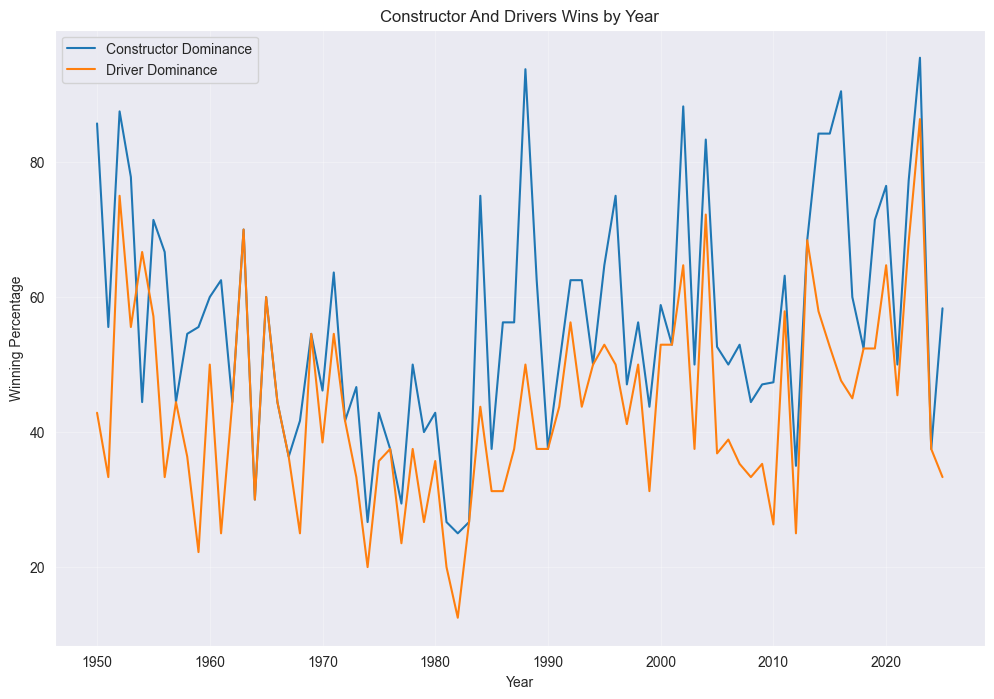

In [57]:
plt.figure(figsize=(12, 8))
plt.plot(
    constructor_season_dominance.year,
    constructor_season_dominance.winning_percent,
    label='Constructor Dominance'
)

plt.plot(
    driver_season_dominance.year,
    driver_season_dominance.winning_percent,
    label='Driver Dominance'
)

plt.xlabel('Year')
plt.ylabel('Winning Percentage')
plt.title('Constructor And Drivers Wins by Year')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


A direct comparison between constructor and driver dominance reveals that constructor-level dominance is consistently higher than driver-level dominance across most seasons. This suggests that Formula 1 dominance is primarily driven by team performance rather than solely by individual drivers. Even during seasons with exceptional driver performances, teams often distribute wins across multiple drivers, reinforcing the structural importance of constructor superiority.


## Overall Conclusion

This notebook analyzed competitive dominance in Formula 1 from 1950 to 2025 by examining race win distributions at both constructor and driver levels.

The results show that Formula 1 has historically exhibited a high degree of competitive concentration. Constructor dominance remains consistently strong across most seasons, indicating that team-level advantages play a decisive role in shaping competitive outcomes. Periods of reduced dominance are relatively rare and are primarily concentrated in the 1970s and early 1980s.

Driver-level dominance displays greater variability, reflecting the impact of exceptional individual performances. However, even during eras defined by standout drivers, dominance at the driver level is generally lower than at the constructor level, suggesting that team strength constrains the extent of individual dominance.

Top-3 dominance analysis further reveals that Formula 1 competition is rarely evenly distributed across the grid. In most seasons, the majority of race wins are captured by a small group of two or three leading teams or drivers, highlighting the oligopolistic nature of competition at the front of the field.

Overall, while dominant teams and drivers change over time, the underlying competitive structure of Formula 1 remains remarkably stable, with sustained concentration of success at the top.
